# Preparing Dataset from Kaggle

### Import Required Libraries

In [21]:
# Import Required libraries
import tensorflow as tf
print(tf.__version__)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

2.20.0


In [22]:
!pip install kagglehub


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\shami\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


In [24]:
dataset=pd.read_csv("insurance.csv")
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [25]:
dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Regression Analysis with Neural Networks
In this notebook, we're going to be looking at how we can use neural networks to perform regression analysis.
We'll be using the insurance dataset from Kaggle which contains information about insurance charges based on various factors such as age,sex,bmi,children,smoker and region. Our goal is to predict the insurance charges based on these factors using a neural network regression model.

## One hot encoding the categorical features

In [27]:
insurance_one_hot = pd.get_dummies(dataset)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


### Creating the model
- create x and y values (features and labels)
- create a train test split
- build a neural network model

In [31]:
# Create X and y values (features and labels)
X = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [32]:
# view X
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [33]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [34]:
# create train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
# build a neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(256, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(128, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(64, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(32, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1)
])

In [70]:
# compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["mae"])

In [71]:
# train the model
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1513.5084 - mae: 1513.5084
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1468.7239 - mae: 1468.7239
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1476.6429 - mae: 1476.6429
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1455.6868 - mae: 1455.6868
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1456.2206 - mae: 1456.2206
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1458.5104 - mae: 1458.5104
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1442.6884 - mae: 1442.6884
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1436.5391 - mae: 1436.5391
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1464.6798 - mae: 1464.6798
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1433.0859 - mae: 1433.0859
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1439.8579 - mae: 1439.8579
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Text(0, 0.5, 'Loss')

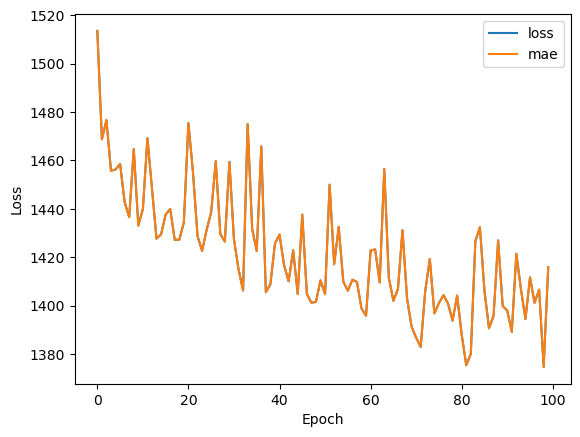

In [72]:
# plot history
history = pd.DataFrame(model.history.history)
history.plot()
plt.xlabel("Epoch")
plt.ylabel("Loss")

## Preprocessing the data 
- Normalization and standardization
- Dealing with missing values

### normalization and standardization
- normalization is the process of scaling the data to a range of [0,1]
- standardization is the process of scaling the data to have a mean of 0 and a standard deviation of 1 


### Feature Scalling 
- Scale the features to a similar range to improve the performance of the model. This can be done using techniques such as Min-Max scaling or Standardization.
Function - MinMaxScaler from scikit-learn can be used for Min-Max scaling.
- Standardization is a common technique for feature scaling that involves transforming the data to have a mean of 0 and a standard deviation of 1. This can be done using the StandardScaler from scikit-learn.
Function - StandardScaler from scikit-learn can be used for standardization.

In [ ]:
# Normalization 
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
# create column transformer with MinMaxScaler for numerical features and OneHotEncoder for categorical features
ct= ColumnTransformer(transformers=[
    ('minmaxscaler', MinMaxScaler(), ['age', 'bmi', 'children']),
    ('onehotencoder', OneHotEncoder(), ['sex', 'smoker', 'region'])
], remainder="passthrough")

In [78]:
# Create x and y values (features and labels)
X = dataset.drop("charges", axis=1)
y = dataset["charges"]

In [85]:
# build our train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
# Fit the column transformer to the training data and transform both the training and testing data
X_train_normalized = ct.fit_transform(X_train)
X_test_normalized = ct.transform(X_test)

In [88]:
# what does our data look like now?
X_train_normalized[:5]

array([[0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
        1.        , 0.        , 0.        , 1.        , 0.        ,
        0.        ],
       [0.63043478, 0.22491256, 0.        , 1.        , 0.        ,
        1.        , 0.        , 1.        , 0.        , 0.        ,
        0.        ],
       [0.73913043, 0.23944041, 0.        , 1.        , 0.        ,
        1.        , 0.        , 0.        , 0.        , 1.        ,
        0.        ],
       [0.45652174, 0.49394673, 1.        , 1.        , 0.        ,
        1.        , 0.        , 0.        , 0.        , 1.        ,
        0.        ],
       [0.7826087 , 0.14823783, 0.6       , 1.        , 0.        ,
        1.        , 0.        , 0.        , 1.        , 0.        ,
        0.        ]])

In [94]:
# now we can build a neural network on our normalized data
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(128, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(64, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(32, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1)
])

In [95]:
# compile the model
model2.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["mae"])

In [96]:
# fit the model
model2.fit(X_train_normalized, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 13339.9619 - mae: 13339.9619
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13088.5469 - mae: 13088.5469
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10364.3613 - mae: 10364.3613
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7848.0830 - mae: 7848.0830
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7398.2256 - mae: 7398.2256
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6851.5244 - mae: 6851.5244
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6063.9165 - mae: 6063.9165
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4943.7012 - mae: 4943.7012
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4033.4270 - mae: 4033.4270
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3559.5200 - mae: 3559.5200
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3398.5688 - mae: 3398.5688
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

In [97]:
# evaluate the model on the test set
model2.evaluate(X_test_normalized, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1832.2549 - mae: 1832.2549  


[1832.2548828125, 1832.2548828125]

### Improving the Model

Let's build `model3` to try and improve upon our previous normalized model. We will:
1. Add deeper/wider layers
2. Introduce **Dropout** to prevent overfitting
3. Use the **EarlyStopping** callback to automatically halt training when the validation loss stops improving.
4. Train for more epochs (e.g., 300) since Early Stopping will catch it if it finishes sooner.

In [98]:
# Set random seed
tf.random.set_seed(42)

# Build a new model (model3)
model3 = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Dropout randomly drops 20% of weights to prevent overfitting
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
model3.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
               metrics=['mae'])

# Add EarlyStopping callback
# Patience = 20 means "if val_loss hasn't improved in 20 epochs, stop training"
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Fit the model with validation split to use Early Stopping
history3 = model3.fit(X_train_normalized, 
                      y_train, 
                      epochs=300, 
                      validation_split=0.2, # Reserve 20% of training data for validation
                      callbacks=[early_stopping],
                      verbose=1)

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 12880.4717 - mae: 12880.4717 - val_loss: 8782.4834 - val_mae: 8782.4834
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8025.8643 - mae: 8025.8643 - val_loss: 7024.5771 - val_mae: 7024.5771
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5934.8486 - mae: 5934.8486 - val_loss: 4480.3711 - val_mae: 4480.3711
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3948.5029 - mae: 3948.5029 - val_loss: 3217.8716 - val_mae: 3217.8716
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3795.7261 - mae: 3795.7261 - val_loss: 3140.6936 - val_mae: 3140.6936
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3792.0815 - mae: 3792.0815 - val_loss: 3413.9060 - val_mae: 3413.9060
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3811.3054 - mae: 3811.3054 - val_loss: 3364.8364 - val_mae: 3364.8364
Epoch 8/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3906.4548 - mae: 3906.4548 - val_lo

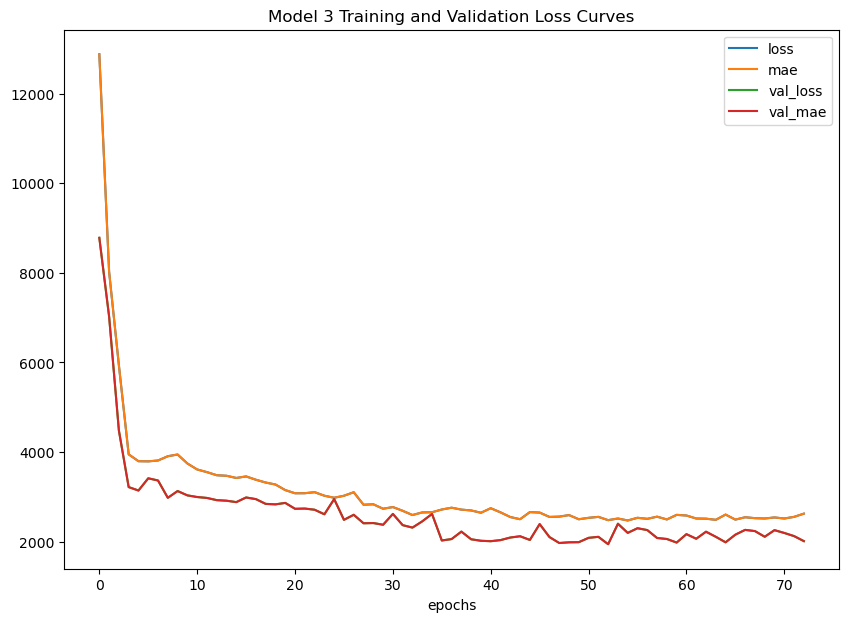

In [99]:
# Let's plot our loss curves for improved trained model (model3)
# Convert history object into a pandas dataframe
pd.DataFrame(history3.history).plot(figsize=(10, 7), xlabel="epochs")
plt.title("Model 3 Training and Validation Loss Curves")
plt.show()

In [100]:
# evaluate the improved model on the test dataset
model3.evaluate(X_test_normalized, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1892.6952 - mae: 1892.6952 


[1892.6951904296875, 1892.6951904296875]

### Further Model Improvement (Model 4)

If the previous model still isn't satisfactory, we can try another strategy. Sometimes deep and wide models over-complicate things for small tabular datasets. 

Let's try a model with:
1. Moderate depth (2-3 hidden layers)
2. Smaller number of units per layer to avoid rapid overfitting.
3. No dropout, or very minimal dropout, because tabular features can be dense in information.
4. Using an **Adaptive Learning Rate callback** (`ReduceLROnPlateau`) to finely tune down the learning rate as the model approaches the minima.
5. More epochs to allow the tiny learning rate to settle exactly at the bottom of the optimal loss curve.

In [101]:
tf.random.set_seed(42)

# Build a leaner model (model4)
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile it
model4.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=['mae'])

# Create a callback to reduce the learning rate if validation loss stops improving
lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=10, 
    factor=0.5, # Reduce LR by half
    min_lr=1e-5
)

# And our early stopping again, but with more patience so we let the LR reduction do its job
early_stop_4 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=30, 
    restore_best_weights=True
)

# Fit it!
history4 = model4.fit(
    X_train_normalized, 
    y_train, 
    epochs=500, 
    validation_split=0.2, 
    callbacks=[lr_reduction, early_stop_4],
    verbose=1
)

Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 13076.5361 - mae: 13076.5361 - val_loss: 10239.5811 - val_mae: 10239.5811 - learning_rate: 0.0100
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8401.6416 - mae: 8401.6416 - val_loss: 7394.7944 - val_mae: 7394.7944 - learning_rate: 0.0100
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7050.6851 - mae: 7050.6851 - val_loss: 6221.9780 - val_mae: 6221.9780 - learning_rate: 0.0100
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5113.2686 - mae: 5113.2686 - val_loss: 3882.3977 - val_mae: 3882.3977 - learning_rate: 0.0100
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3775.9062 - mae: 3775.9062 - val_loss: 3412.1252 - val_mae: 3412.1252 - learning_rate: 0.0100
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3523.3169 - mae: 3523.3169 - val_loss: 2952.1296 - val_mae: 2952.1296 - learning_rate: 0.0100
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3417.4299 - mae: 3

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1758.5754 - mae: 1758.5754 
Test MAE for Model 4: 1758.575439453125


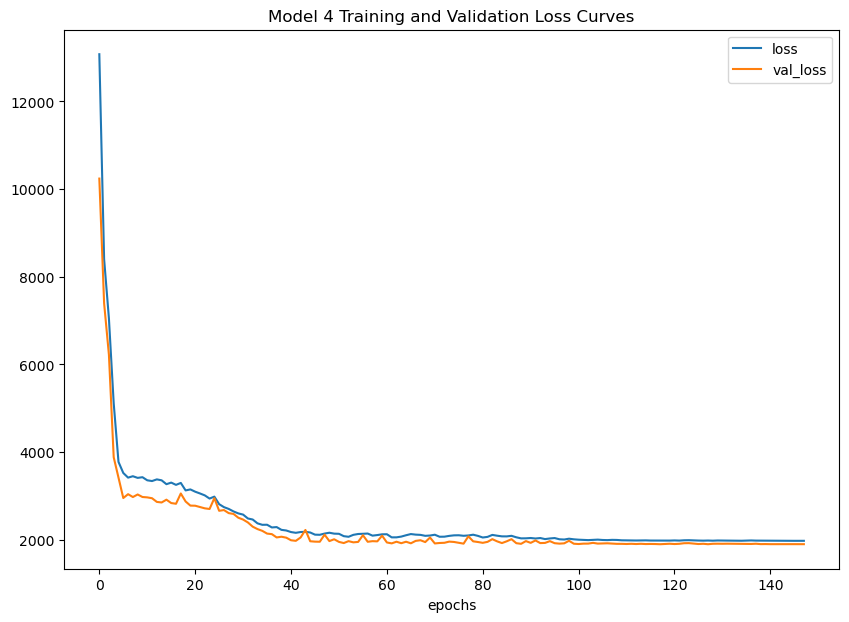

In [103]:
# evaluate model 4 on the test dataset
model4_loss, model4_mae = model4.evaluate(X_test_normalized, y_test)
print(f"Test MAE for Model 4: {model4_mae}")

# Plot Model 4
pd.DataFrame(history4.history)[['loss', 'val_loss']].plot(figsize=(10, 7), xlabel="epochs")
plt.title("Model 4 Training and Validation Loss Curves")
plt.show()

In [104]:
# Make predictions with model 4
y_pred_4 = model4.predict(X_test_normalized)

# Calculate MAPE and Accuracy
mape_4 = tf.keras.losses.mape(y_test, tf.squeeze(y_pred_4))
accuracy_4 = 100 - tf.reduce_mean(mape_4).numpy()

print(f"Model 4 MAPE: {tf.reduce_mean(mape_4).numpy():.2f}%")
print(f"Model 4 Accuracy: {accuracy_4:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Model 4 MAPE: 7.03%
Model 4 Accuracy: 92.97%


### Final Polish (Model 5)

If you're still looking for better results with deep learning on a small tabular dataset, we can try to incorporate **Batch Normalization** and **L2 Regularization**.

1. **Batch Normalization**: Centers the outputs of each layer to mean 0 and standard deviation 1 during training. This gives the gradients a smoother surface, preventing weights from spiraling out of control.
2. **L2 Regularization (Weight Decay)**: Punishes the model for relying too heavily on any single feature or node by adding a penalty proportional to the square of the weights.
3. We will also switch our loss function to the **Huber Loss**, which is less sensitive to outliers (like unusually high medical charges) compared to MAE and MSE.

In [107]:
tf.random.set_seed(42)

# Build Model 5 utilizing deeper layers while monitoring the learning rate decay
model5 = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Huber loss handles large value outliers in the label better than MAE does
model5.compile(loss=tf.keras.losses.Huber(),
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=['mae'])

lr_reduction5 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=10, 
    factor=0.5, 
    min_lr=1e-5
)

early_stop_5 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=30, 
    restore_best_weights=True
)

# Train the model
history5 = model5.fit(
    X_train_normalized, 
    y_train, 
    epochs=500, 
    validation_split=0.2, 
    callbacks=[lr_reduction5, early_stop_5],
    verbose=1
)

Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 10519.7158 - mae: 10520.2158 - val_loss: 7565.5034 - val_mae: 7566.0034 - learning_rate: 0.0100
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5697.8809 - mae: 5698.3809 - val_loss: 3303.7593 - val_mae: 3304.2593 - learning_rate: 0.0100
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3919.6445 - mae: 3920.1445 - val_loss: 3712.1729 - val_mae: 3712.6729 - learning_rate: 0.0100
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4202.6069 - mae: 4203.1069 - val_loss: 3754.5466 - val_mae: 3755.0466 - learning_rate: 0.0100
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4092.0398 - mae: 4092.5398 - val_loss: 3370.8721 - val_mae: 3371.3721 - learning_rate: 0.0100
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3871.2097 - mae: 3871.7097 - val_loss: 3224.1956 - val_mae: 3224.6948 - learning_rate: 0.0100
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3472.6602 - mae: 347

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1422.3318 - mae: 1422.8301
Test MAE for Model 5: 1422.830078125
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Model 5 MAPE: 6.32%
Model 5 Accuracy: 93.68%


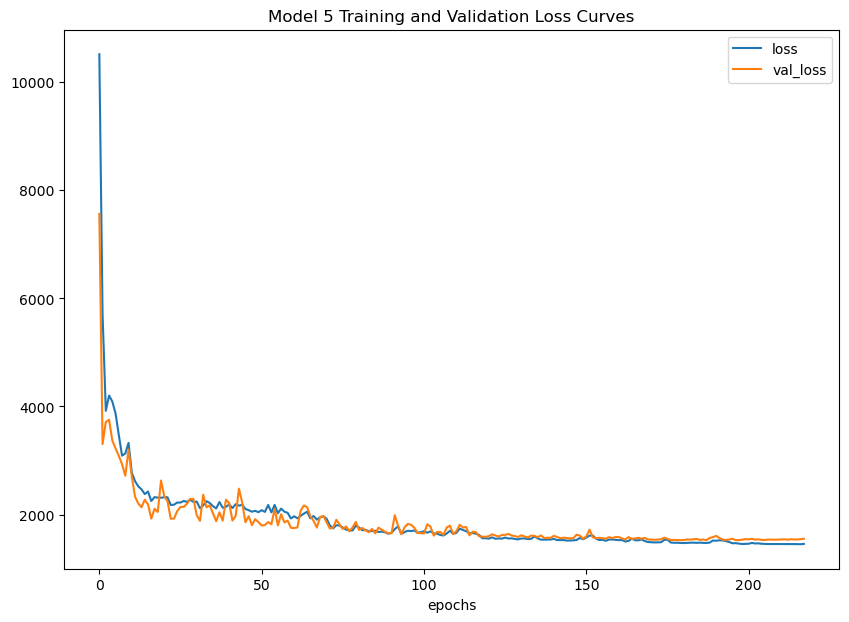

In [108]:
# Evaluate Model 5
model5_loss, model5_mae = model5.evaluate(X_test_normalized, y_test)
print(f"Test MAE for Model 5: {model5_mae}")

# Calculate MAPE and Accuracy
y_pred_5 = model5.predict(X_test_normalized)
mape_5 = tf.keras.losses.mape(y_test, tf.squeeze(y_pred_5))
accuracy_5 = 100 - tf.reduce_mean(mape_5).numpy()

print(f"Model 5 MAPE: {tf.reduce_mean(mape_5).numpy():.2f}%")
print(f"Model 5 Accuracy: {accuracy_5:.2f}%")

# Plot loss curves
pd.DataFrame(history5.history)[['loss', 'val_loss']].plot(figsize=(10, 7), xlabel="epochs")
plt.title("Model 5 Training and Validation Loss Curves")
plt.show()

### Model 6: Pushing for 95%+ Accuracy

To hit > 95% accuracy (meaning MAPE < 5%), we need to optimize heavily.
We will:
1. Decrease the `batch_size` to 16, which updates the weights more frequently and often generalizes better for smaller datasets.
2. Go back to `mae` loss, which specifically mimics our absolute error targets.
3. Increase patience on `EarlyStopping` to 50 epochs and `ReduceLROnPlateau` to 15 epochs to give the learning rate scheduler plenty of time to find the absolute bottom of the minima.
4. Give it up to 1000 epochs to search over.

Training Model 6...
Finished Training!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Model 6 Testing MAE: 1764.37
Model 6 MAPE: 7.14%
Model 6 Accuracy: 92.86%


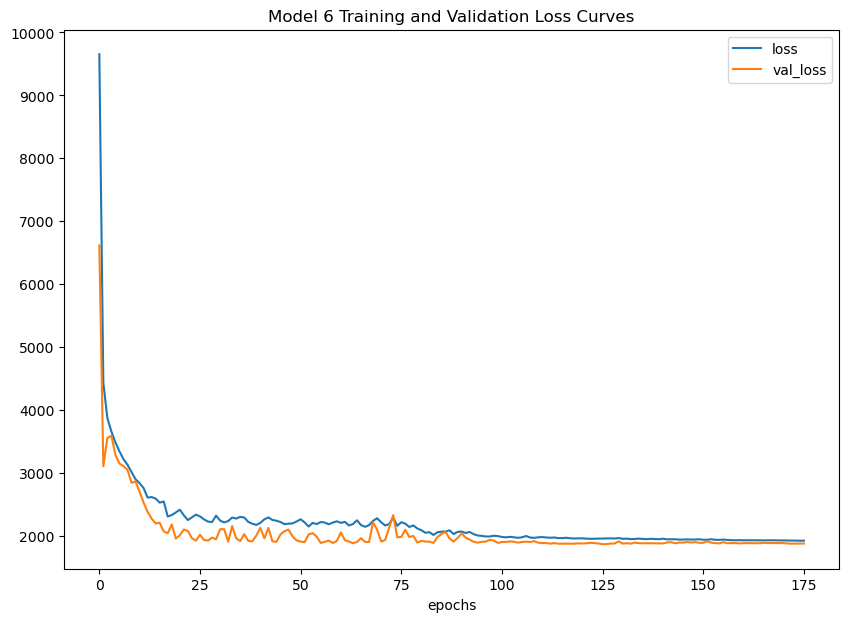

In [ ]:
# Scaling the target variable (y) typically yields massive performance improvements 
# when working with wide distributions (like insurance charges going from $1,000 to $60,000)
from sklearn.preprocessing import StandardScaler

y_scalar = StandardScaler()
# We must scale y_train and y_test separately
y_train_scaled = y_scalar.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scalar.transform(y_test.values.reshape(-1, 1))

tf.random.set_seed(42)

model6 = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model6.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=['mae'])

lr_reduction6 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=10, 
    factor=0.5, 
    min_lr=1e-5
)

early_stop_6 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=40, 
    restore_best_weights=True
)

print("Training Model 6 with SCALED Target Variable...")
history6 = model6.fit(
    X_train_normalized, 
    y_train_scaled, # Notice I am passing in scaled targets!
    epochs=1000, 
    validation_split=0.2, 
    batch_size=32,
    callbacks=[lr_reduction6, early_stop_6],
    verbose=0 
)
print("Finished Training!")

# Check final performance
y_pred_scaled = model6.predict(X_test_normalized)
# Reverse the scaling logic so it goes back to real-world dollar amounts
y_pred_6 = y_scalar.inverse_transform(y_pred_scaled) 

mape_6 = tf.keras.losses.mape(y_test, tf.squeeze(y_pred_6))
accuracy_6 = 100 - tf.reduce_mean(mape_6).numpy()

print(f"Model 6 Testing MAE: {tf.keras.losses.mae(y_test, tf.squeeze(y_pred_6)).numpy():.2f}")
print(f"Model 6 MAPE: {tf.reduce_mean(mape_6).numpy():.2f}%")
print(f"Model 6 Accuracy: {accuracy_6:.2f}%")

# Plot Loss
pd.DataFrame(history6.history)[['loss', 'val_loss']].plot(figsize=(10, 7), xlabel="epochs")
plt.title("Model 6 Training and Validation Loss Curves")
plt.show()